# Self-practice: DBSCAN Machine Learning Clustering Algorithm

<a href="https://youtu.be/VO_uzCU_nKw" target="_blank">
    <img src="https://i.ytimg.com/an_webp/VO_uzCU_nKw/mqdefault_6s.webp?du=3000&sqp=CLzhsdIG&rs=AOn4CLB4-6cVZwZeSDMYCZDs-sc93Bopxw" width="450" style="border-radius: 8px;">
</a>

<h3> DBSCAN Clustering Coding Tutorial in Python & Scikit-Learn </h3>
<p>Click the image to watch on YouTube</p>

---


In [13]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv('california_housing_train.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


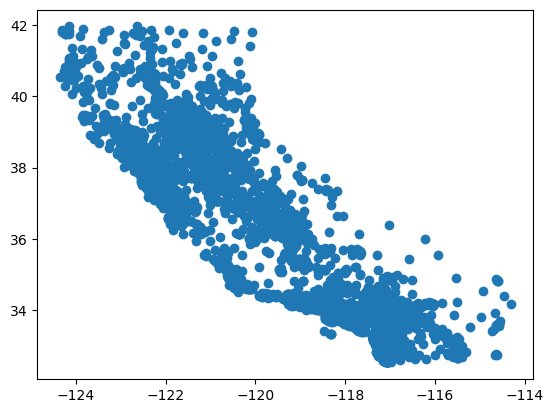

In [14]:
lat_long = df[['latitude', 'longitude']]
lat, longg = df.latitude, df.longitude

plt.scatter(longg, lat)

In [15]:
from sklearn.cluster import DBSCAN

X = lat_long.to_numpy()

dbscan_cluster_model = DBSCAN(eps=0.2, min_samples=15).fit(X)
dbscan_cluster_model

,eps,0.2
,min_samples,15
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [16]:
df['cluster'] = dbscan_cluster_model.labels_
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,cluster
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,-1
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,-1
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,-1
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,-1
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,-1
...,...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0,9
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0,9
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0,-1
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0,-1


In [17]:
df['cluster'].value_counts()

cluster
 2    9065
 4    6999
-1     401
 7     219
 9      95
 0      84
 6      77
 3      21
 5      18
 1      15
 8       6
Name: count, dtype: int64

In [18]:
import plotly.express as px
fig = px.scatter(x=longg, y=lat, color=df[f'cluster'])
fig.show()

In [19]:
from sklearn.metrics import silhouette_score as ss

ss(X, df['cluster'])

0.25721908993836395

In [20]:
epsilons = np.linspace(0.01, 1, num=15)
epsilons

array([0.01      , 0.08071429, 0.15142857, 0.22214286, 0.29285714,
       0.36357143, 0.43428571, 0.505     , 0.57571429, 0.64642857,
       0.71714286, 0.78785714, 0.85857143, 0.92928571, 1.        ])

In [24]:
min_samples = np.arange(2, 20, step=3)
min_samples

array([ 2,  5,  8, 11, 14, 17])

In [ ]:
import itertools

combinations = list(itertools.product(epsilons, min_samples))
combinations

[(np.float64(0.01), np.int64(2)),
 (np.float64(0.01), np.int64(5)),
 (np.float64(0.01), np.int64(8)),
 (np.float64(0.01), np.int64(11)),
 (np.float64(0.01), np.int64(14)),
 (np.float64(0.01), np.int64(17)),
 (np.float64(0.08071428571428571), np.int64(2)),
 (np.float64(0.08071428571428571), np.int64(5)),
 (np.float64(0.08071428571428571), np.int64(8)),
 (np.float64(0.08071428571428571), np.int64(11)),
 (np.float64(0.08071428571428571), np.int64(14)),
 (np.float64(0.08071428571428571), np.int64(17)),
 (np.float64(0.15142857142857144), np.int64(2)),
 (np.float64(0.15142857142857144), np.int64(5)),
 (np.float64(0.15142857142857144), np.int64(8)),
 (np.float64(0.15142857142857144), np.int64(11)),
 (np.float64(0.15142857142857144), np.int64(14)),
 (np.float64(0.15142857142857144), np.int64(17)),
 (np.float64(0.22214285714285714), np.int64(2)),
 (np.float64(0.22214285714285714), np.int64(5)),
 (np.float64(0.22214285714285714), np.int64(8)),
 (np.float64(0.22214285714285714), np.int64(11)),
 (

In [28]:
N = len(combinations)
N

90

In [29]:
def get_scores_and_labels(combinations, X):
    scores = []
    all_labels_list = []

    for i, (eps, num_samples) in enumerate(combinations):
        dbscan_cluster_model = DBSCAN(eps=eps, min_samples=num_samples).fit(X)
        labels = dbscan_cluster_model.labels_
        labels_set = set(labels)
        num_clusters = len(labels_set)
        if -1 in labels_set:
            num_clusters -= 1
        if (num_clusters <2) or (num_clusters > 50):
            scores.append(-10)
            all_labels_list.append('bad')
            c = (eps, num_samples)
            print(f"Combination {c} on interation {i+1} of {N} has {num_clusters} clusters. Moving on")
            continue

        scores.append(ss(X,labels))
        all_labels_list.append(labels)
        print(f"Index: {i}, Score: {scores[-1]}, Labels: {all_labels_list[-1]}, NumClusters: {num_clusters}")

    best_index = np.argmax(scores)
    best_parameters = combinations[best_index]
    best_labels = all_labels_list[best_index]
    best_score = scores[best_index]

    return{'best epsilon' : best_parameters[0],
            'best_min_samples' : best_parameters[1],
            'best_labels' : best_labels,
            'best_score' : best_score}
        

best_dict = get_scores_and_labels(combinations, X)


Combination (np.float64(0.01), np.int64(2)) on interation 1 of 90 has 2170 clusters. Moving on
Combination (np.float64(0.01), np.int64(5)) on interation 2 of 90 has 945 clusters. Moving on
Combination (np.float64(0.01), np.int64(8)) on interation 3 of 90 has 394 clusters. Moving on
Combination (np.float64(0.01), np.int64(11)) on interation 4 of 90 has 179 clusters. Moving on
Combination (np.float64(0.01), np.int64(14)) on interation 5 of 90 has 75 clusters. Moving on
Index: 5, Score: -0.73513712011191, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 36
Combination (np.float64(0.08071428571428571), np.int64(2)) on interation 7 of 90 has 130 clusters. Moving on
Combination (np.float64(0.08071428571428571), np.int64(5)) on interation 8 of 90 has 70 clusters. Moving on
Combination (np.float64(0.08071428571428571), np.int64(8)) on interation 9 of 90 has 54 clusters. Moving on
Index: 9, Score: 0.22411847164890658, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 50
Index: 10, Score: 0.23025110810